<a href="https://colab.research.google.com/github/habibasati018-debug/NETFLIX-DATA-ANALYSIS/blob/main/NETFLIX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING  LIBARARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOADING DATASET

In [2]:
netflix_data = pd.read_csv('/content/netflix1.csv')
netflix_data


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV


SHAPE OF DATASET

In [3]:
netflix_data.shape

(8790, 10)

DATA INFO

In [4]:
netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


CHAKING FOR NULL VALUES

In [5]:
netflix_data.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


CHECK UNIQUE VALUES

In [6]:
netflix_data.nunique()

,0
show_id,8790
type,2
title,8787
director,4528
country,86
date_added,1713
release_year,74
rating,14
duration,220
listed_in,513


CHECK FOR DUPLICATE VALUES

In [7]:
netflix_data.duplicated().sum()

np.int64(0)

DROP NULL VALUES

In [8]:
netflix_data=netflix_data.dropna()
netflix_data.shape

(8790, 10)

CONVERT DATE TIME FORMATE

In [9]:
netflix_data["date_added"] = pd.to_datetime(netflix_data['date_added'])
netflix_data['day_added']= netflix_data['date_added'].dt.day
netflix_data['year_added']= netflix_data['date_added'].dt.year
netflix_data['month_added']= netflix_data['date_added'].dt.month
netflix_data['year_added'].astype(int)
netflix_data['day_added'].astype(int)

,day_added
0,25
1,24
2,24
3,22
4,24
...,...
8785,17
8786,13
8787,15
8788,23


### **DATA VISUALIZATION**

TYPE: MOVIES AND TV SHOWS

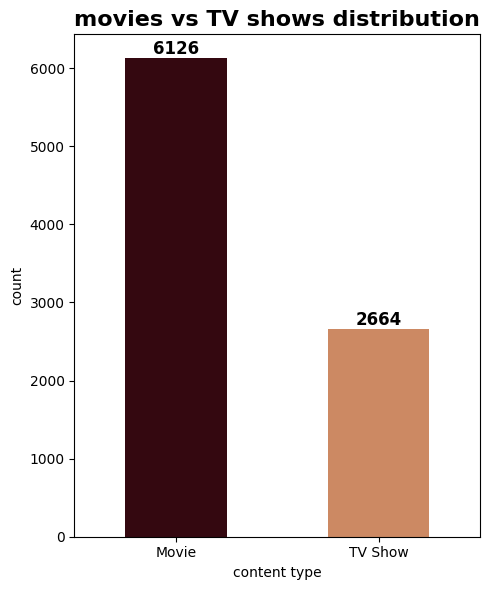

In [10]:
plt.figure(figsize=(5,6))
ax = sns.countplot(
                   x='type',
                   data= netflix_data,
                   hue='type',
                   palette=['#3B010B','#DD8452'],
                   width=0.5,
                   legend=False)
plt.title("movies vs TV shows distribution", fontsize=16, fontweight='bold')
plt.xlabel("content type")
plt.ylabel("count")

for p in ax.patches:
  ax.annotate(f'{int(p.get_height())}',
              (p.get_x()+p.get_width()/2, p.get_height()),
              ha='center', va='bottom',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

RATING OF SHOWS AND MOVIES

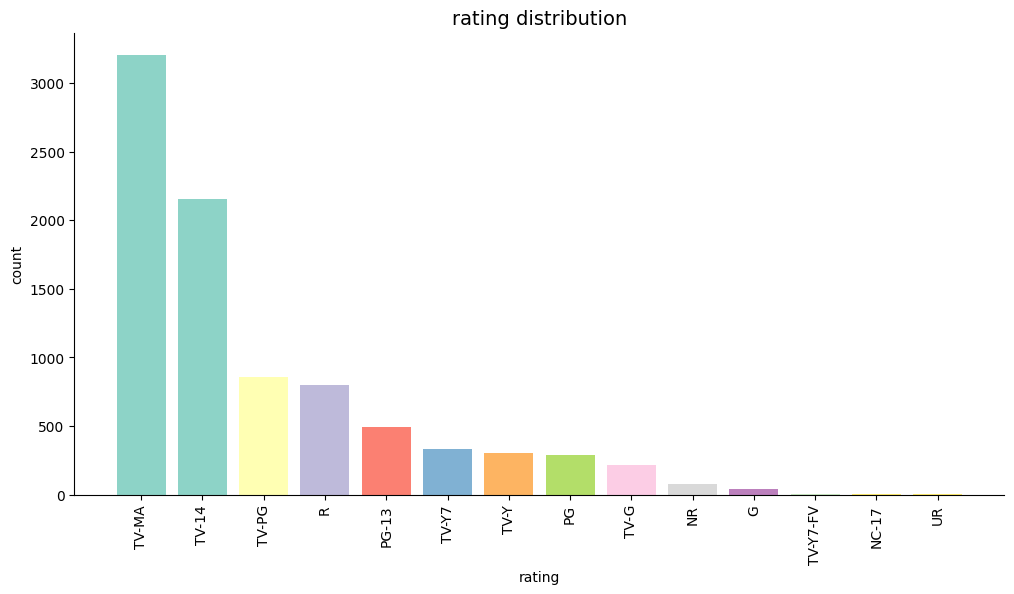

In [11]:
rating_counts = netflix_data['rating'].value_counts()
plt.figure(figsize=(12,6))
colors = plt.cm.Set3(np.linspace(0,1,len(rating_counts)))
plt.bar(rating_counts.index, rating_counts.values, color=colors)

plt.title("rating distribution", fontsize=14)
plt.xlabel("rating")
plt.ylabel("count")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(rotation=90)
plt.show()

RELATION BETWEEN TYPE NAD RATING

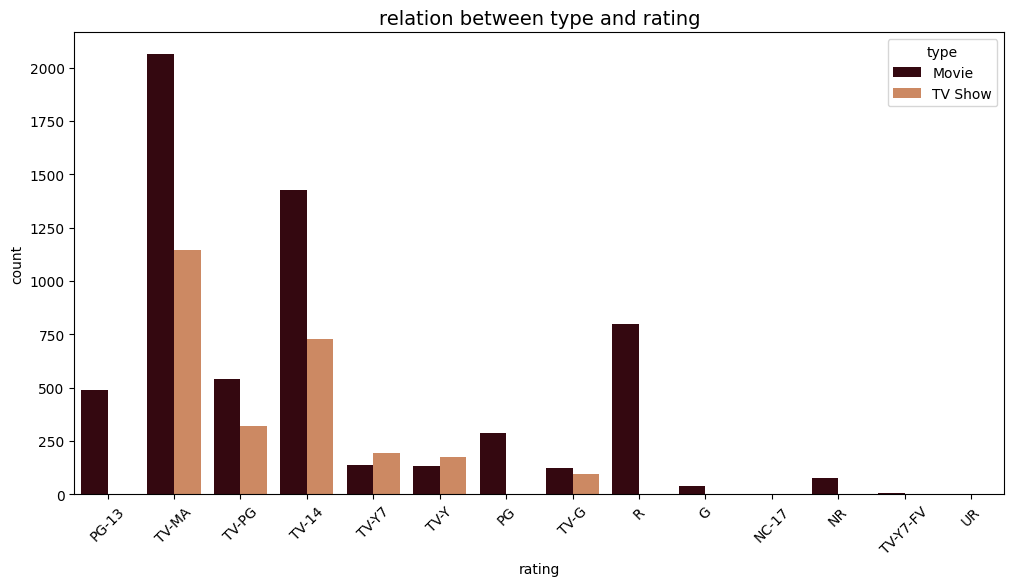

In [12]:
plt.figure(figsize=(12,6))
sns.countplot(data=netflix_data, x='rating', hue='type', palette=['#3B010B','#DD8452'])
plt.title("relation between type and rating", fontsize=14)
plt.xlabel("rating")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.show()

WOEDCLOUD :COUNTRY

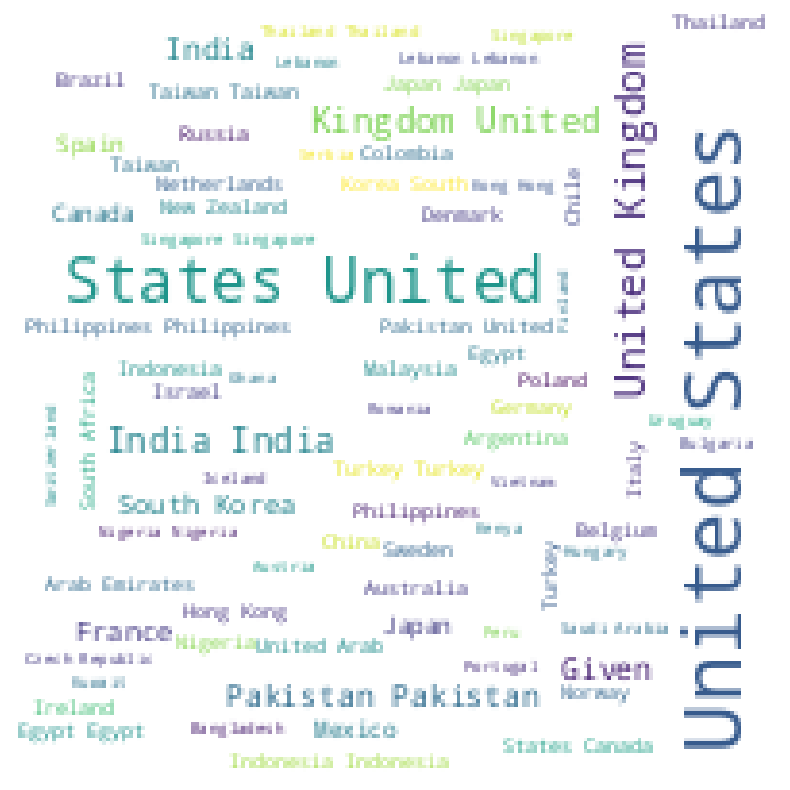

In [14]:
from wordcloud import WordCloud

plt.subplots(figsize=(10,10))
wordcloud_obj = WordCloud(
                          background_color='white',
                          width= 200,
                          height= 200
                         ).generate(" ".join(netflix_data.country))
plt.imshow(wordcloud_obj)
plt.axis('off')
plt.savefig('country.png')
plt.show()